# Initial code

In [ ]:

import os
import re

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

from sklearn.decomposition import PCA

from src.utils.cfRNA_utils import build_counts_matrix

In [ ]:
lope_samples = [
    "s1", "s2", "s3", "s4", "s5", "s6", "s7", "s8", "s9", "s10",
]

eope_samples = [
    "s11", "s12", "s13", "s14", "s15", "s16", "s17", "s18", "s19", "s20",
]

ctr_samples = ["s21", "s22", "s23", "s24", "s25", "s26", "s27", "s28", "s29", "s30",
               "s31", "s32", "s33", "s34", "s35", "s36", "s37", "s38", "s39", "s40",
               "s41", "s42", "s43", "s44", "s45", "s46", "s47", "s48", "s49", "s50",
              ]

dict_types_samples = {"LOPE": lope_samples,
                      "EOPE": eope_samples,
                      "Control": ctr_samples}


In [3]:
all_samples = lope_samples + eope_samples + ctr_samples

In [4]:
print("Samples CTR [", len(ctr_samples), "] | EOPE [", len(eope_samples), "] | LOPE [", len(lope_samples), "]")

Samples CTR [ 131 ] | EOPE [ 42 ] | LOPE [ 43 ]


### Figure rRNA fraction

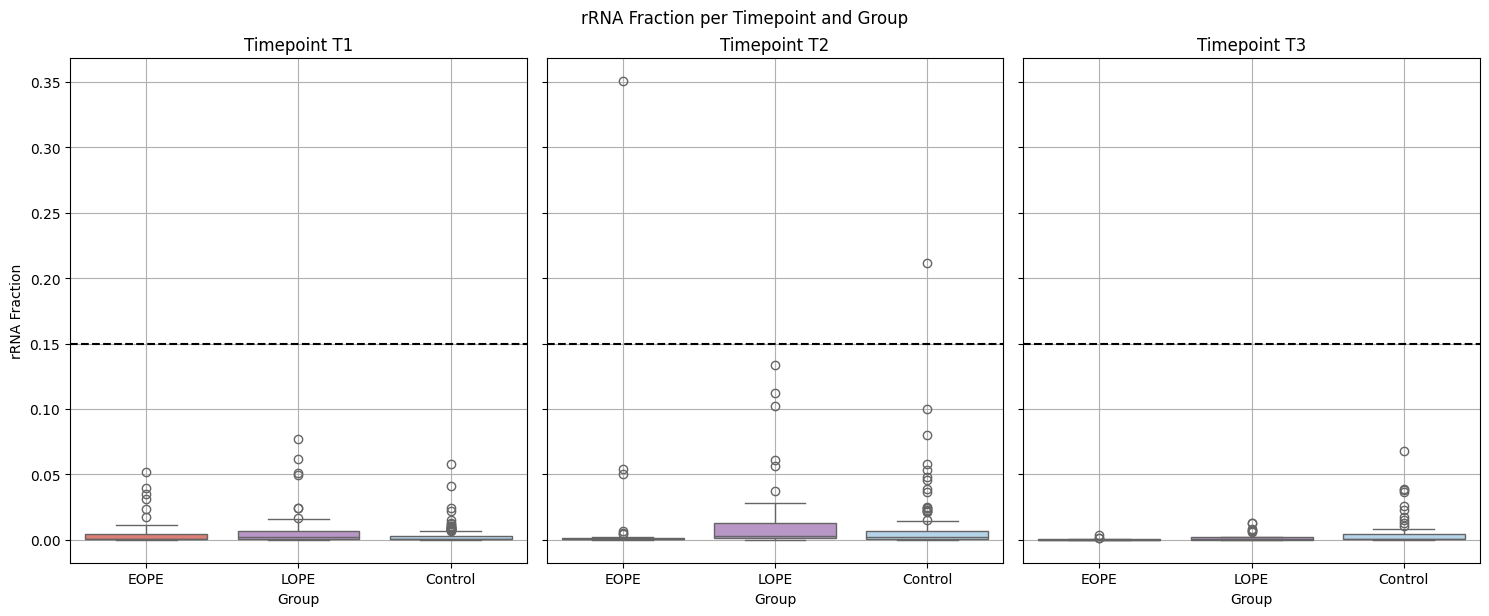

In [ ]:
# Define timepoints
timepoints = ['T1', 'T2', 'T3']

# Base path where the different runs are stored
base_folder = "./data/counts-t1-t2-t3-eope-lope-v7/"

# List all runs in the base folder
runs = os.listdir(base_folder)

# Initialize a DataFrame to store all results
all_rRNA_results = pd.DataFrame(columns=['sample', 'timepoint', 'group', 'rRNA_fraction', 'run'])

dedupCounts = build_counts_matrix.build_counts_matrix(base_folder, sample_pattern=r".*-T[0-9]*")

# Set "GeneID" as the index (equivalent to column_to_rownames in R)
# dupCounts.set_index("GeneID", inplace=True)
dedupCounts.set_index("GeneID", inplace=True)

# Read the 'biotypes.txt' file (fixed path for this file)
gtfDatabase = pd.read_csv("./data/utilities/biotypes-gene-id-gene-name.txt", sep="\t")
gtfDatabase['GeneID'] = gtfDatabase['gene_name'].fillna(gtfDatabase['gene_ID'])

# Combine dedupCounts with gtfDatabase based on 'GeneID'
biotype_df = dedupCounts.merge(gtfDatabase, left_on='GeneID', right_on='GeneID', how='left')

# Initialize an empty DataFrame for the results of this run
plot_df = pd.DataFrame(columns=["gene_type", "counts", "sample", "freq", "label"])

# Process each sample in dedupCounts
samples = dedupCounts.columns.tolist()

for s in samples:
    rows2add = (
        biotype_df[['gene_name', s, 'gene_type']]
        .rename(columns={s: 'sample_counts'})
        .groupby('gene_type')['sample_counts'].sum().reset_index()
        .assign(freq=lambda x: round(x['sample_counts'] / x['sample_counts'].sum(), 3))
        .sort_values(by='freq', ascending=False)
        .assign(label=lambda x: (x['freq'] * 100).astype(str) + '%', sample=s)
    )
    plot_df = pd.concat([plot_df, rows2add], ignore_index=True)

# Filter for rRNA gene types
plot_df['gene_type'] = plot_df['gene_type'].apply(lambda x: 'rRNA' if x in ["Mt_rRNA", "rRNA_pseudogene", "rRNA"] else 'non_rRNA')

# Group by sample and gene type, summing counts
rRNA_plot = plot_df.groupby(['sample', 'gene_type']).agg({'sample_counts': 'sum'}).reset_index()

# Calculate frequency
rRNA_plot = rRNA_plot.groupby('sample').apply(
    lambda x: x.assign(freq=round(x['sample_counts'] / x['sample_counts'].sum(), 6))
).reset_index(drop=True)

# Filter only the rRNA fraction
rRNA_plot = rRNA_plot[rRNA_plot['gene_type'] == 'rRNA']

# Iterate over groups (EOPE, LOPE, Control) and timepoints
for group, samples_group in dict_types_samples.items():
    for sample in samples_group:
        # Extract the base name of the sample without the '-Tn' suffix
        sample_base = sample.split('-')[0] + "-" + sample.split('-')[1]
        
        # Find corresponding samples in rRNA_plot for T1, T2, and T3
        for timepoint in timepoints:
            sample_with_timepoint = f"{sample_base}-{timepoint}"
            
            if sample_with_timepoint in rRNA_plot['sample'].values:
                # Filter rRNA data for the current sample and timepoint
                sample_data = rRNA_plot[rRNA_plot['sample'] == sample_with_timepoint]
                
                if not sample_data.empty:
                    rRNA_fraction = sample_data['freq'].values[0]
                else:
                    rRNA_fraction = 0.0
                
                # Add results to the global DataFrame
                new_row = pd.DataFrame({
                    'sample': [sample_with_timepoint],
                    'timepoint': [timepoint],
                    'group': [group],
                    'rRNA_fraction': [rRNA_fraction],
                })

                all_rRNA_results = pd.concat([all_rRNA_results, new_row], ignore_index=True)


# Define a custom color palette
custom_palette = {
    "Control": "#AED6F1",  # Blue
    "EOPE": "#EC7063",  # Red
    "LOPE": "#BB8FCE"  # Purple
}

# Ensure groups are always in the same order: LOPE, EOPE, Control
all_rRNA_results['group'] = pd.Categorical(all_rRNA_results['group'], categories=['EOPE', 'LOPE', 'Control'], ordered=True)

# Generate boxplots for each timepoint
fig, axes = plt.subplots(1, len(timepoints), figsize=(15, 6), sharey=True)

for i, timepoint in enumerate(timepoints):
    ax = axes[i]
    sns.boxplot(x='group', y='rRNA_fraction', data=all_rRNA_results[all_rRNA_results['timepoint'] == timepoint], ax=ax, palette=custom_palette)
    ax.axhline(0.15, ls='--', color='black')  # Horizontal line for rRNA fraction 0.1
    ax.set_title(f'Timepoint {timepoint}')
    ax.set_xlabel('Group')
    if i == 0:
        ax.set_ylabel('rRNA Fraction')
    else:
        ax.set_ylabel('')
    ax.grid()

plt.tight_layout()
plt.suptitle('rRNA Fraction per Timepoint and Group', y=1.02)
plt.show()


### DNA Contamination

100%|██████████| 34/34 [00:00<00:00, 113.88it/s]


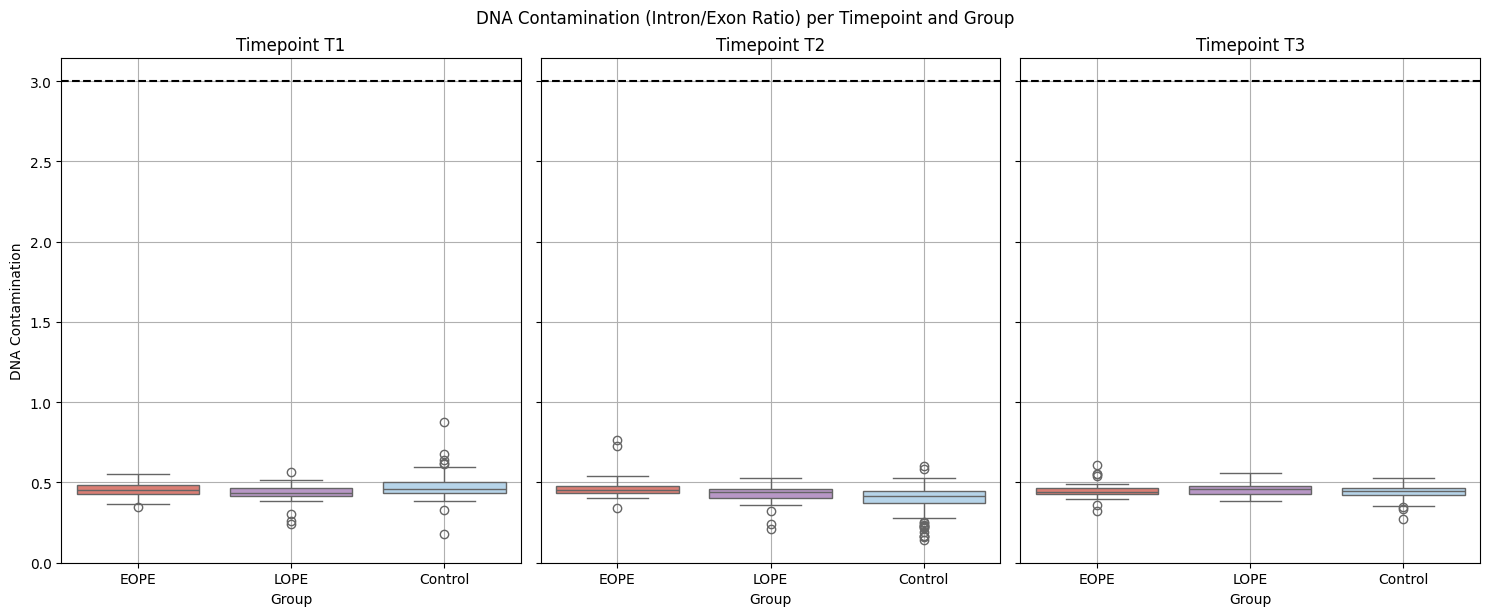

In [ ]:
timepoints = ['T1', 'T2', 'T3']

# Base path where the different folders are located
base_folder = "./data/multiqc_data/"
folds = os.listdir(base_folder)

# Initialize a DataFrame to store all results
all_contamination_metrics = pd.DataFrame(columns=['sample', 'timepoint', 'group', 'intronExonRatio', 'run'])

# Iterate over RUN-X folders
for fold in tqdm(folds):
    run_path = os.path.join(base_folder, fold)
    metrics_file = os.path.join(run_path, "./data/multiqc_data/multiqc_rseqc_read_distribution.txt")

    # Check if the read distribution file exists
    if os.path.isfile(metrics_file):
        # Read the read distribution metrics file
        distribution_metrics = pd.read_csv(metrics_file, sep="\t")

        # Filter samples that contain "RSeQC"
        distribution_metrics = distribution_metrics[distribution_metrics['Sample'].str.contains("RSeQC")]

        # Extract sample names (removing the '_RSeQC...' suffix)
        distribution_metrics['sample'] = distribution_metrics['Sample'].apply(lambda x: re.sub(r'_RSeQC.*', '', x))

        # Calculate necessary columns
        distribution_metrics['allExons'] = (
            distribution_metrics['cds_exons_tag_count'] + 
            distribution_metrics['5_utr_exons_tag_count'] + 
            distribution_metrics['3_utr_exons_tag_count']
        )
        distribution_metrics['intronExonRatio'] = distribution_metrics['introns_tag_count'] / distribution_metrics['allExons']

        # Select relevant columns
        distribution_metrics = distribution_metrics[['sample', 'intronExonRatio']]

        # Iterate over groups (EOPE, LOPE, Control) and timepoints
        for group, samples_group in dict_types_samples.items():
            for sample in samples_group:
                # Extract the base name of the sample without the '-Tn' suffix
                sample_base = sample.split('-')[0] + "-" + sample.split('-')[1]
                
                # Find corresponding samples in distribution_metrics for T1, T2, and T3
                for timepoint in timepoints:
                    sample_with_timepoint = f"{sample_base}-{timepoint}"
                    
                    if sample_with_timepoint in distribution_metrics['sample'].values:
                        # Filter contamination data for the current sample and timepoint
                        sample_data = distribution_metrics[distribution_metrics['sample'] == sample_with_timepoint]
                        
                        if not sample_data.empty:
                            intronExonRatio = sample_data['intronExonRatio'].values[0]
                        else:
                            intronExonRatio = 0.0
                        
                        # Add results to the global DataFrame
                        new_row = pd.DataFrame({
                            'sample': [sample_with_timepoint],
                            'timepoint': [timepoint],
                            'group': [group],
                            'intronExonRatio': [intronExonRatio],
                            'run': [fold]
                        })

                        all_contamination_metrics = pd.concat([all_contamination_metrics, new_row], ignore_index=True)

# Define a custom color palette
custom_palette = {
    "Control": "#AED6F1",  # Blue
    "EOPE": "#EC7063",  # Red
    "LOPE": "#BB8FCE"  # Purple
}

# Ensure groups are always in the same order: EOPE, LOPE, Control
all_contamination_metrics['group'] = pd.Categorical(all_contamination_metrics['group'], categories=["EOPE", 'LOPE', 'Control'], ordered=True)

# Generate plots for DNA Contamination (Intron/Exon Ratio)
fig, axes = plt.subplots(1, len(timepoints), figsize=(15, 6), sharey=True)

for i, timepoint in enumerate(timepoints):
    ax = axes[i]
    sns.boxplot(x='group', y='intronExonRatio', data=all_contamination_metrics[all_contamination_metrics['timepoint'] == timepoint], ax=ax, palette=custom_palette)
    ax.axhline(3, ls='--', color='black')  # Reference line at y=3 for DNA contamination
    ax.set_title(f'Timepoint {timepoint}')
    ax.set_xlabel('Group')
    if i == 0:
        ax.set_ylabel('DNA Contamination')
    else:
        ax.set_ylabel('')
    ax.grid()

plt.tight_layout()
plt.suptitle('DNA Contamination (Intron/Exon Ratio) per Timepoint and Group', y=1.02)
plt.show()

### RNA Degradation

100%|██████████| 34/34 [00:00<00:00, 111.20it/s]


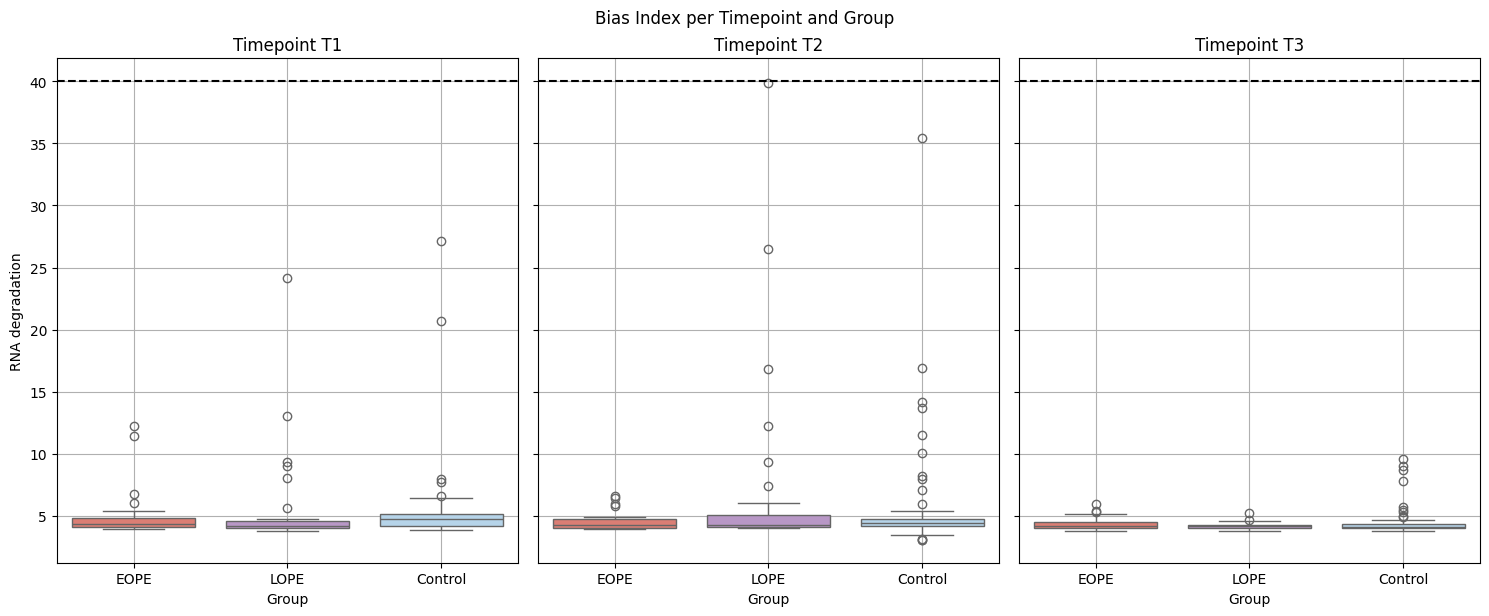

In [ ]:
timepoints = ['T1', 'T2', 'T3']

# Base path where the different folders are located
base_folder = "./data/multiqc_data/"
folds = os.listdir(base_folder)

# Initialize a DataFrame to store all results
all_bias_indices = pd.DataFrame(columns=['sample', 'timepoint', 'group', 'biasIndex', 'run'])

# Iterate over RUN-X folders
for fold in tqdm(folds):
    run_path = os.path.join(base_folder, fold)
    metrics_file = os.path.join(run_path, "./data/multiqc_data/multiqc_rseqc_read_distribution.txt")

    # Check if the read distribution file exists
    if os.path.isfile(metrics_file):
        # Read the read distribution metrics file
        distribution_metrics = pd.read_csv(metrics_file, sep="\t")

        # Filter samples that contain "RSeQC"
        distribution_metrics = distribution_metrics[distribution_metrics['Sample'].str.contains("RSeQC")]

        # Extract sample names (removing the '_RSeQC...' suffix)
        distribution_metrics['sample'] = distribution_metrics['Sample'].apply(lambda x: re.sub(r'_RSeQC.*', '', x))
        samples_remove = []
        for id_sample, sample in enumerate(distribution_metrics["sample"]):
            sample_name = sample[0:9]
            if sample_name not in all_samples:
                samples_remove.append(id_sample)
        distribution_metrics = distribution_metrics.drop(samples_remove)

        # Calculate necessary columns
        distribution_metrics['allExons'] = (
            distribution_metrics['cds_exons_tag_count'] + 
            distribution_metrics['5_utr_exons_tag_count'] + 
            distribution_metrics['3_utr_exons_tag_count']
        )
        distribution_metrics['bias_index'] = 100*distribution_metrics['3_utr_exons_tag_count'] / distribution_metrics['allExons']
        # distribution_metrics["bias_index"] = distribution_metrics['3_utr_exons_tag_count']/100

        # Select relevant columns
        distribution_metrics = distribution_metrics[['sample', 'bias_index']]

        # Iterate over groups (EOPE, LOPE, Control) and timepoints
        for group, samples_group in dict_types_samples.items():
            for sample in samples_group:
                # Extract the base name of the sample without the '-Tn' suffix
                sample_base = sample.split('-')[0] + "-" + sample.split('-')[1]
                
                # Find corresponding samples in distribution_metrics for T1, T2, and T3
                for timepoint in timepoints:
                    sample_with_timepoint = f"{sample_base}-{timepoint}"
                    
                    if sample_with_timepoint in distribution_metrics['sample'].values:
                        # Filter contamination data for the current sample and timepoint
                        sample_data = distribution_metrics[distribution_metrics['sample'] == sample_with_timepoint]
                        
                        if not sample_data.empty:
                            biasIndex = sample_data['bias_index'].values[0]
                        else:
                            biasIndex = 0.0
                        
                        # Add results to the global DataFrame
                        new_row = pd.DataFrame({
                            'sample': [sample_with_timepoint],
                            'timepoint': [timepoint],
                            'group': [group],
                            'biasIndex': [biasIndex],
                            'run': [fold]
                        })

                        all_bias_indices = pd.concat([all_bias_indices, new_row], ignore_index=True)

# Define a custom color palette
custom_palette = {
    "Control": "#AED6F1",  # Blue
    "EOPE": "#EC7063",  # Red
    "LOPE": "#BB8FCE"  # Purple
}

# Ensure groups are always in the same order: EOPE, LOPE, Control
all_bias_indices['group'] = pd.Categorical(all_bias_indices['group'], categories=['EOPE', 'LOPE', 'Control'], ordered=True)

# Generate plots for biasIndex
fig, axes = plt.subplots(1, len(timepoints), figsize=(15, 6), sharey=True)

for i, timepoint in enumerate(timepoints):
    ax = axes[i]
    sns.boxplot(x='group', y='biasIndex', data=all_bias_indices[all_bias_indices['timepoint'] == timepoint], ax=ax, palette=custom_palette)
    ax.axhline(40, ls='--', color='black')  # Reference line if needed
    ax.set_title(f'Timepoint {timepoint}')
    ax.set_xlabel('Group')
    if i == 0:
        ax.set_ylabel('RNA degradation')
    else:
        ax.set_ylabel('')
    ax.grid()

plt.tight_layout()
plt.suptitle('Bias Index per Timepoint and Group', y=1.02)
plt.show()

In [10]:
all_bias_indices
for i in range(len(all_bias_indices)):
    if all_bias_indices["biasIndex"][i] > 40:
        print(all_bias_indices["sample"][i], all_bias_indices["biasIndex"][i])

### PCA

#### EOPE vs CTR

In [ ]:
main_path_v7 = "./data/differential_expression/"

In [21]:
# Load and combine the data for T1, T2, and T3
dfs = []
for path in [
    main_path_v7 + 'limma_counts_normal_eope_ctr_t1_not_hb.csv',
    main_path_v7 + 'limma_counts_normal_eope_ctr_t2_not_hb.csv',
]:
    df_temp = pd.read_csv(path, index_col=0).T
    # Extract the timepoint (T1, T2, T3) from the sample names
    df_temp['Timepoint'] = df_temp.index.str.extract(r'-(T[123])$', expand=False)
    # Remove the timepoint suffix (-Tn) to unify sample names
    df_temp.index = df_temp.index.str.replace(r'-T[123]$', '', regex=True)
    dfs.append(df_temp)

# Combine the DataFrames for T1, T2, and T3 into a single DataFrame
df_combined = pd.concat(dfs)

# Filter samples for EOPE and Control groups
df_eope = df_combined[df_combined.index.isin(dict_types_samples["EOPE"])]
df_control = df_combined[df_combined.index.isin(dict_types_samples["Control"])]

# Combine both groups into a single DataFrame for PCA
df_pca_eope = pd.concat([df_eope, df_control]).dropna(axis=1)

# Preserve the 'Timepoint' column in a separate variable
timepoint_column = df_pca_eope.pop('Timepoint')

# Prepare the data for PCA
x_eope = df_pca_eope.values
pca_eope = PCA(n_components=2)
pca_result_eope = pca_eope.fit_transform(x_eope)

# Create a DataFrame with the PCA results and group labels
pca_df_eope_t1_t2 = pd.DataFrame(data=pca_result_eope, columns=['PC1', 'PC2'], index=df_pca_eope.index)
pca_df_eope_t1_t2['Group'] = ['EOPE' if sample in dict_types_samples["EOPE"] else 'Control' for sample in pca_df_eope_t1_t2.index]

# Add the 'Timepoint' column back to pca_df
pca_df_eope_t1_t2['Timepoint'] = timepoint_column.values

In [22]:
### Outliers
lower_bound_pc2 = pca_df_eope_t1_t2["PC2"].mean() - 3 * pca_df_eope_t1_t2["PC2"].std()
upper_bound_pc2 = pca_df_eope_t1_t2["PC2"].mean() + 3 * pca_df_eope_t1_t2["PC2"].std()
lower_bound_pc1 = pca_df_eope_t1_t2["PC1"].mean() - 3 * pca_df_eope_t1_t2["PC1"].std()
upper_bound_pc1 = pca_df_eope_t1_t2["PC1"].mean() + 3 * pca_df_eope_t1_t2["PC1"].std()

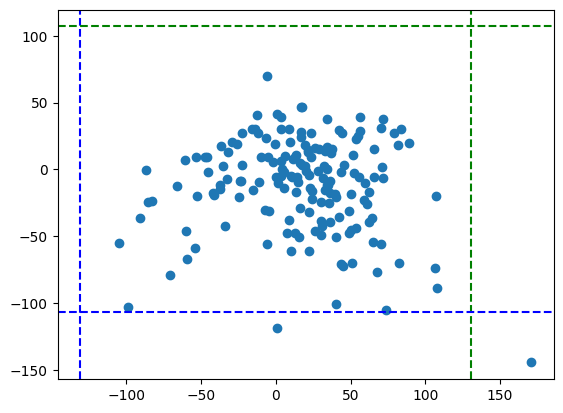

In [25]:
pc1_values = [pci_1 for i, pci_1 in enumerate(pca_df_eope_t1_t2["PC1"]) if pca_df_eope_t1_t2["Timepoint"][i] == "T2"]
pc2_values = [pci_1 for i, pci_1 in enumerate(pca_df_eope_t1_t2["PC2"]) if pca_df_eope_t1_t2["Timepoint"][i] == "T2"]
plt.scatter(pc1_values, pc2_values)
plt.axvline(x=lower_bound_pc1, color='blue', linestyle='--', label=f"Media - 3*std ({lower_bound_pc1:.2f})")
plt.axvline(x=upper_bound_pc1, color='green', linestyle='--', label=f"Media + 3*std ({upper_bound_pc1:.2f})")
plt.axhline(y=lower_bound_pc2, color='blue', linestyle='--', label=f"Media - 3*std ({lower_bound_pc2:.2f})")
plt.axhline(y=upper_bound_pc2, color='green', linestyle='--', label=f"Media + 3*std ({upper_bound_pc2:.2f})")
plt.show()

In [ ]:
# Load T3

df_temp = pd.read_csv(main_path_v7 + 'limma_counts_normal_eope_ctr_t3_not_hb.csv', index_col=0).T
# Extract the timepoint (T1, T2, T3) from the sample names
df_temp['Timepoint'] = df_temp.index.str.extract(r'-(T[123])$', expand=False)
# Remove the timepoint suffix (-Tn) to unify sample names
df_temp.index = df_temp.index.str.replace(r'-T[123]$', '', regex=True)

# Combine the DataFrames for T1, T2, and T3 into a single DataFrame
df_combined = pd.concat([df_temp])

# Filter samples for EOPE and Control groups
df_eope = df_combined[df_combined.index.isin(dict_types_samples["EOPE"])]
df_control = df_combined[df_combined.index.isin(dict_types_samples["Control"])]

# Combine both groups into a single DataFrame for PCA
df_pca_eope = pd.concat([df_eope, df_control]).dropna(axis=1)

# Preserve the 'Timepoint' column in a separate variable
timepoint_column = df_pca_eope.pop('Timepoint')

# Prepare the data for PCA
x_eope = df_pca_eope.values
pca_eope = PCA(n_components=2)
pca_result_eope = pca_eope.fit_transform(x_eope)

# Create a DataFrame with the PCA results and group labels
pca_df_eope_t3 = pd.DataFrame(data=pca_result_eope, columns=['PC1', 'PC2'], index=df_pca_eope.index)
pca_df_eope_t3['Group'] = ['EOPE' if sample in dict_types_samples["EOPE"] else 'Control' for sample in pca_df_eope_t3.index]

# Add the 'Timepoint' column back to pca_df
pca_df_eope_t3['Timepoint'] = timepoint_column.values

In [218]:
lower_bound_pc2 = pca_df_eope_t3["PC2"].mean() - 3 * pca_df_eope_t3["PC2"].std()
upper_bound_pc2 = pca_df_eope_t3["PC2"].mean() + 3 * pca_df_eope_t3["PC2"].std()
lower_bound_pc1 = pca_df_eope_t3["PC1"].mean() - 3 * pca_df_eope_t3["PC1"].std()
upper_bound_pc1 = pca_df_eope_t3["PC1"].mean() + 3 * pca_df_eope_t3["PC1"].std()

In [211]:
pca_df_eope = pd.concat([pca_df_eope_t1_t2, pca_df_eope_t3])

In [ ]:
pca_df_eope.to_csv("./data/pca_outliers/pca_eope_control_v7.csv")

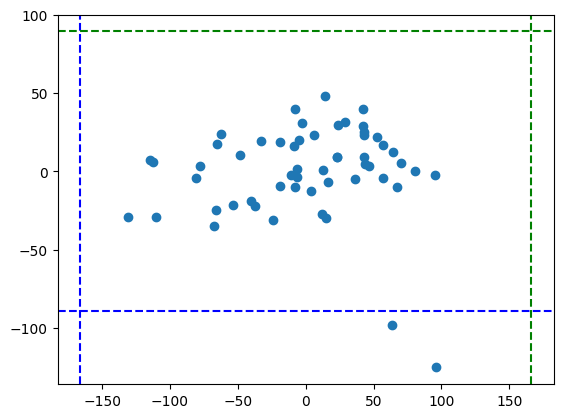

In [ ]:
pc1_values = [pci_1 for i, pci_1 in enumerate(pca_df_eope["PC1"]) if pca_df_eope["Timepoint"][i] == "T3"]
pc2_values = [pci_1 for i, pci_1 in enumerate(pca_df_eope["PC2"]) if pca_df_eope["Timepoint"][i] == "T3"]
plt.scatter(pc1_values, pc2_values)
plt.axvline(x=lower_bound_pc1, color='blue', linestyle='--', label=f"Media - 3*std ({lower_bound_pc1:.2f})")
plt.axvline(x=upper_bound_pc1, color='green', linestyle='--', label=f"Media + 3*std ({upper_bound_pc1:.2f})")
plt.axhline(y=lower_bound_pc2, color='blue', linestyle='--', label=f"Media - 3*std ({lower_bound_pc2:.2f})")
plt.axhline(y=upper_bound_pc2, color='green', linestyle='--', label=f"Media + 3*std ({upper_bound_pc2:.2f})")
plt.show()

#### LOPE vs CTR

In [16]:
# Load and combine the data for T1, T2, and T3
dfs = []
for path in [
    main_path_v7 + 'limma_counts_normal_lope_ctr_t1_not_hb.csv',
    main_path_v7 + 'limma_counts_normal_lope_ctr_t2_not_hb.csv',
    # main_path_v7 + 'limma_counts_normal_lope_ctr_t3_not_hb.csv',
]:
    # Load the data and transpose it
    df_temp = pd.read_csv(path, index_col=0).T
    # Extract the timepoint (T1, T2, T3) from the sample names
    df_temp['Timepoint'] = df_temp.index.str.extract(r'-(T[123])$', expand=False)
    # Remove the timepoint suffix (-Tn) to unify sample names
    df_temp.index = df_temp.index.str.replace(r'-T[123]$', '', regex=True)
    dfs.append(df_temp)

# Combine the DataFrames for T1, T2, and T3 into a single DataFrame
df_combined = pd.concat(dfs)

# Filter samples for EOPE and Control groups
df_lope = df_combined[df_combined.index.isin(dict_types_samples["LOPE"])]
df_control = df_combined[df_combined.index.isin(dict_types_samples["Control"])]

# Combine both groups into a single DataFrame for PCA
df_pca = pd.concat([df_lope, df_control]).dropna(axis=1)

# Preserve the 'Timepoint' column in a separate variable
timepoint_column = df_pca.pop('Timepoint')

# Prepare the data for PCA
X = df_pca.values
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X)

# Create a DataFrame with the PCA results and group labels
pca_df_lope_t1_t2 = pd.DataFrame(data=pca_result, columns=['PC1', 'PC2'], index=df_pca.index)
pca_df_lope_t1_t2['Group'] = ['LOPE' if sample in dict_types_samples["LOPE"] else 'Control' for sample in pca_df_lope_t1_t2.index]

# Add the 'Timepoint' column back to pca_df
pca_df_lope_t1_t2['Timepoint'] = timepoint_column.values

In [17]:
lower_bound_pc2 = pca_df_lope_t1_t2["PC2"].mean() - 3 * pca_df_lope_t1_t2["PC2"].std()
upper_bound_pc2 = pca_df_lope_t1_t2["PC2"].mean() + 3 * pca_df_lope_t1_t2["PC2"].std()
lower_bound_pc1 = pca_df_lope_t1_t2["PC1"].mean() - 3 * pca_df_lope_t1_t2["PC1"].std()
upper_bound_pc1 = pca_df_lope_t1_t2["PC1"].mean() + 3 * pca_df_lope_t1_t2["PC1"].std()

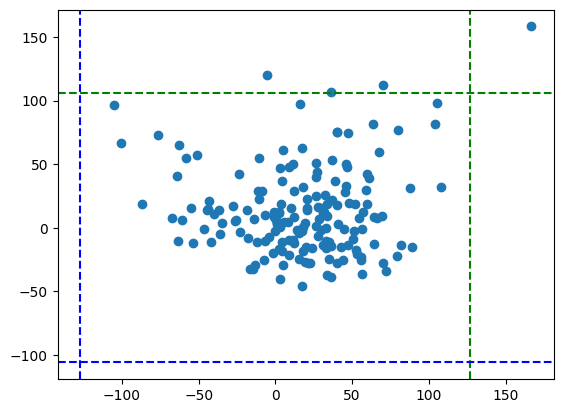

In [19]:
pc1_values = [pci_1 for i, pci_1 in enumerate(pca_df_lope_t1_t2["PC1"]) if pca_df_lope_t1_t2["Timepoint"][i] == "T2"]
pc2_values = [pci_1 for i, pci_1 in enumerate(pca_df_lope_t1_t2["PC2"]) if pca_df_lope_t1_t2["Timepoint"][i] == "T2"]
plt.scatter(pc1_values, pc2_values)
plt.axvline(x=lower_bound_pc1, color='blue', linestyle='--', label=f"Media - 3*std ({lower_bound_pc1:.2f})")
plt.axvline(x=upper_bound_pc1, color='green', linestyle='--', label=f"Media + 3*std ({upper_bound_pc1:.2f})")
plt.axhline(y=lower_bound_pc2, color='blue', linestyle='--', label=f"Media - 3*std ({lower_bound_pc2:.2f})")
plt.axhline(y=upper_bound_pc2, color='green', linestyle='--', label=f"Media + 3*std ({upper_bound_pc2:.2f})")
plt.show()

In [10]:
# Load T3
df_temp = pd.read_csv(main_path_v7 + 'limma_counts_normal_lope_ctr_t3_not_hb.csv', index_col=0).T
# Extract the timepoint (T1, T2, T3) from the sample names
df_temp['Timepoint'] = df_temp.index.str.extract(r'-(T[123])$', expand=False)
# Remove the timepoint suffix (-Tn) to unify sample names
df_temp.index = df_temp.index.str.replace(r'-T[123]$', '', regex=True)

# Combine the DataFrames for T1, T2, and T3 into a single DataFrame
df_combined = pd.concat([df_temp])

# Filter samples for LOPE and Control groups
df_lope = df_combined[df_combined.index.isin(dict_types_samples["LOPE"])]
df_control = df_combined[df_combined.index.isin(dict_types_samples["Control"])]

# Combine both groups into a single DataFrame for PCA
df_pca_lope = pd.concat([df_lope, df_control]).dropna(axis=1)

# Preserve the 'Timepoint' column in a separate variable
timepoint_column = df_pca_lope.pop('Timepoint')

# Prepare the data for PCA
x_lope = df_pca_lope.values
pca_lope = PCA(n_components=2)
pca_result_lope = pca_lope.fit_transform(x_lope)

# Create a DataFrame with the PCA results and group labels
pca_df_lope_t3 = pd.DataFrame(data=pca_result_lope, columns=['PC1', 'PC2'], index=df_pca_lope.index)
pca_df_lope_t3['Group'] = ['LOPE' if sample in dict_types_samples["LOPE"] else 'Control' for sample in pca_df_lope_t3.index]

# Add the 'Timepoint' column back to pca_df
pca_df_lope_t3['Timepoint'] = timepoint_column.values

In [11]:
lower_bound_pc2 = pca_df_lope_t3["PC2"].mean() - 3 * pca_df_lope_t3["PC2"].std()
upper_bound_pc2 = pca_df_lope_t3["PC2"].mean() + 3 * pca_df_lope_t3["PC2"].std()
lower_bound_pc1 = pca_df_lope_t3["PC1"].mean() - 3 * pca_df_lope_t3["PC1"].std()
upper_bound_pc1 = pca_df_lope_t3["PC1"].mean() + 3 * pca_df_lope_t3["PC1"].std()

In [12]:
for i, sample in enumerate(pca_df_lope_t3.index):
    if pca_df_lope_t3["PC1"][i] < lower_bound_pc1 or pca_df_lope_t3["PC1"][i] > upper_bound_pc1 :
        print(sample, pca_df_lope_t3["Timepoint"][i], pca_df_lope_t3["Group"][i], "PCA 1: ", pca_df_lope_t3["PC1"][i])
    if pca_df_lope_t3["PC2"][i] < lower_bound_pc2 or pca_df_lope_t3["PC2"][i] > upper_bound_pc2 :
        print(sample, pca_df_lope_t3["Timepoint"][i], pca_df_lope_t3["Group"][i], "PCA 2: ", pca_df_lope_t3["PC2"][i])

In [13]:
pca_df_lope = pd.concat([pca_df_lope_t1_t2, pca_df_lope_t3])

In [ ]:
pca_df_lope.to_csv("./data/pca_outliers/pca_lope_control_v7.csv")